# Notebook 04 — SARIMAX with Fourier Terms for Annual Seasonality
**Station: Hirsch · SARIMA order: (2,1,2)(1,0,2)[7]**

SARIMA with `s=7` captures the weekly cycle but cannot directly model the annual cycle at `s=365`
(too many seasonal lags). The solution: add Fourier sin/cos pairs as exogenous regressors to
represent the annual pattern, then find the optimal number of pairs K.

| Part | Content |
|------|---------|
| 1 | Fourier feature generation and visualisation |
| 2 | Data preparation (splits + Fourier features for each K) |
| 3 | Fit SARIMAX(2,1,2)(1,0,2)[7] for K ∈ {0, 1, 2, 3, 4} |
| 4 | Comparison table and optimal K selection |
| 5 | Forecast visualisation: baseline vs optimal SARIMAX |
| 6 | Residual diagnostics for optimal model |
| 7 | BONUS — log-transform test (multiplicative seasonality) |

In [1]:
import sys, warnings, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from scipy.stats import probplot

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'legend.frameon'   : False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
MODELS  = Path('../results/models')
PREDS   = Path('../results/predictions')
for p in [FIGURES, TABLES, MODELS, PREDS]:
    p.mkdir(parents=True, exist_ok=True)

# ── SARIMA order (2,1,2)(1,0,2)[7] selected in nb03 over (1,1,1)(1,0,1)[7] ──
ORDER          = (2, 1, 2)
SEASONAL_ORDER = (1, 0, 2, 7)
K_VALUES       = [0, 1, 2, 3, 4]   # 0 = no Fourier (baseline)
ANNUAL_PERIOD  = 365.25             # accounts for leap years
REF_DATE       = '2013-01-01'       # anchor for absolute time index

STATION    = 'Hirsch'
TRAIN_START, TRAIN_END = '2013-01-01', '2022-12-31'
VAL_START,   VAL_END   = '2023-01-01', '2023-12-31'
TEST_START,  TEST_END  = '2024-01-01', '2026-04-30'

np.random.seed(42)

# ── notebook prefix: all figures saved as nb04_<name>.png ────────────────────
NB = 'nb04'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print('Setup complete.')

Setup complete.


---
## Part 1 — Fourier Feature Generation

Each Fourier pair k contributes two regressors:
$$\sin_k = \sin\!\left(\frac{2\pi k\, t}{365.25}\right), \quad
\cos_k = \cos\!\left(\frac{2\pi k\, t}{365.25}\right)$$

where $t$ is the number of days since a fixed reference date (2013-01-01). Using an absolute
time index rather than day-of-year avoids small phase discontinuities at year boundaries and
ensures train/val/test Fourier terms lie on the same continuous sinusoidal curve.

- **K=1:** one harmonic — captures the broad summer/winter shape
- **K=2:** adds a secondary peak (e.g., spring shoulder season)
- **K=3–4:** finer detail; diminishing returns beyond K=4 for daily cycling data

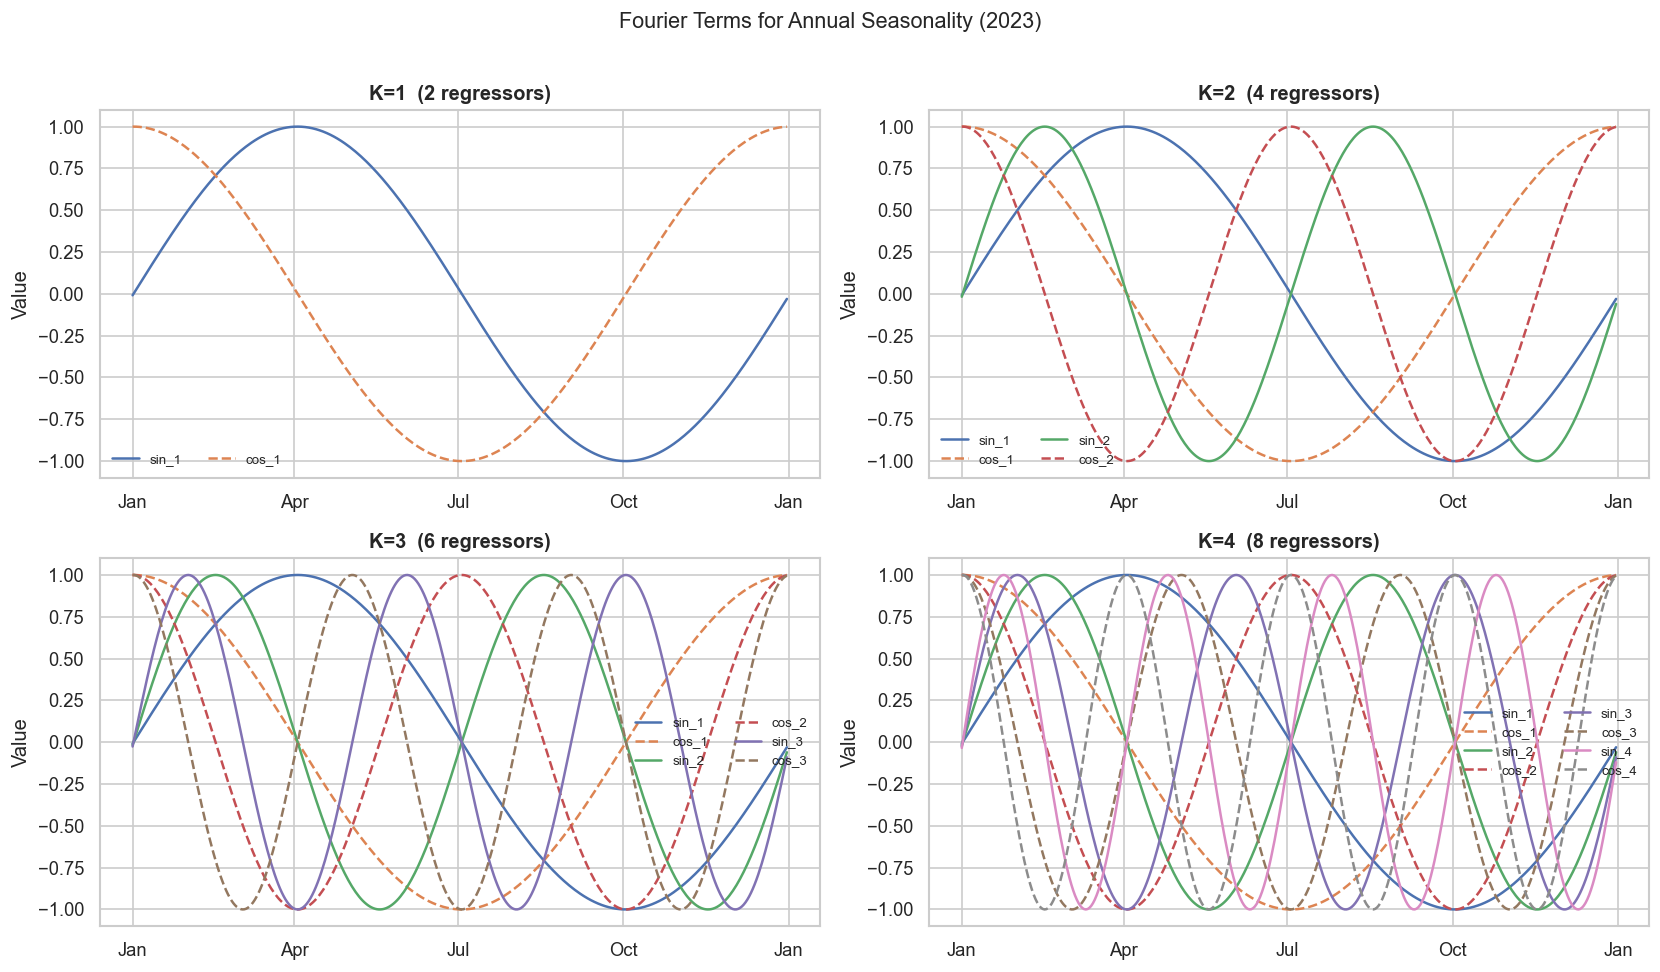

  saved → results/figures/nb04_fig_01_fourier_terms.png


In [2]:
def create_fourier_terms(dates, K, period=365.25, ref_date='2013-01-01'):
    """
    Generate K Fourier sin/cos pairs for annual seasonality.

    Parameters
    ----------
    dates    : DatetimeIndex or date-like sequence
    K        : int — number of sin/cos pairs; K=0 returns empty DataFrame
    period   : float — 365.25 to account for leap years
    ref_date : str — anchor date so phases are consistent across splits

    Returns
    -------
    DataFrame with columns [sin_1, cos_1, ..., sin_K, cos_K], shape (n, 2K)
    """
    dates = pd.DatetimeIndex(dates)
    if K == 0:
        return pd.DataFrame(index=dates)   # empty — no Fourier exog

    # Absolute day count from reference: guarantees phase continuity across year boundaries
    t = (dates - pd.Timestamp(ref_date)).days.values.astype(float)
    cols = {}
    for k in range(1, K + 1):
        angle = 2 * np.pi * k * t / period
        cols[f'sin_{k}'] = np.sin(angle)
        cols[f'cos_{k}'] = np.cos(angle)
    return pd.DataFrame(cols, index=dates)


# ── Visualise the Fourier terms for one calendar year ────────────────────────
example_dates = pd.date_range('2023-01-01', '2023-12-31', freq='D')
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, K in zip(axes.flat, [1, 2, 3, 4]):
    ft = create_fourier_terms(example_dates, K)
    for col in ft.columns:
        style = '-' if col.startswith('sin') else '--'
        ax.plot(example_dates, ft[col], linestyle=style, lw=1.5, label=col)
    ax.set_title(f'K={K}  ({2*K} regressors)')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

fig.suptitle('Fourier Terms for Annual Seasonality (2023)', fontsize=13, y=1.01)
plt.tight_layout()
savefig('fig_01_fourier_terms')

---
## Part 2 — Data Preparation

In [3]:
from data_loader import load_master_data

df_full = load_master_data('../data/processed/master_bike_data.csv')
hirsch  = (df_full[df_full['station'] == STATION]
           .set_index('date')['total']
           .sort_index())

train = hirsch[TRAIN_START:TRAIN_END].copy()
val   = hirsch[VAL_START  :VAL_END  ].copy()
test  = hirsch[TEST_START :TEST_END ].copy()

# ── Continuous train series (for SARIMAX; interpolate any residual gaps) ─────
train_full = train.reindex(
    pd.date_range(TRAIN_START, TRAIN_END, freq='D')
).interpolate(method='linear', limit=7)

tv_index = pd.date_range(TRAIN_START, VAL_END, freq='D')
tv_series = pd.concat([train_full, val]).reindex(tv_index).interpolate(method='linear', limit=7)

# ── Pre-generate Fourier features for all K values and all splits ─────────────
fourier = {}   # fourier[K] = {'train': df, 'val': df, 'test': df, 'tv': df}
for K in K_VALUES:
    fourier[K] = {
        'train': create_fourier_terms(train_full.index, K),
        'val'  : create_fourier_terms(val.index,        K),
        'test' : create_fourier_terms(test.index,       K),
        'tv'   : create_fourier_terms(tv_index,         K),
    }

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name:<6} {split.index[0].date()} → {split.index[-1].date()}  '
          f'({len(split):,} days  |  missing: {split.isna().sum()})')

print(f'\nFourier features generated for K ∈ {K_VALUES}')
print(f'  Example K=4 train shape: {fourier[4]["train"].shape}')

Train  2013-01-01 → 2022-12-31  (3,652 days  |  missing: 0)
Val    2023-01-01 → 2023-12-31  (365 days  |  missing: 0)
Test   2024-01-01 → 2026-04-30  (851 days  |  missing: 0)

Fourier features generated for K ∈ [0, 1, 2, 3, 4]
  Example K=4 train shape: (3652, 8)


---
## Part 3 — Fit SARIMAX for K ∈ {0, 1, 2, 3, 4}

**K=0** is the pure SARIMA baseline — no annual exogenous regressors, weekly seasonality only.  
**K≥1** adds Fourier pairs to capture the annual cycle.

Each model is:
1. Fit on `train` → forecast `val`
2. Refit on `train+val` (warm start) → forecast `test`

In [4]:
def evaluate_forecast(y_true, y_pred, horizon):
    """RMSE, MAE, MAPE over non-overlapping h-day windows."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmses, maes, mapes = [], [], []
    for i in range(0, len(y_true), horizon):
        yt = y_true[i : i + horizon]
        yp = y_pred[i : i + horizon]
        if len(yt) < max(1, horizon // 2):
            continue
        rmses.append(np.sqrt(np.mean((yt - yp) ** 2)))
        maes.append(np.mean(np.abs(yt - yp)))
        nonzero = yt > 0
        if nonzero.sum() > 0:
            mapes.append(np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100)
    return {
        'RMSE': round(float(np.mean(rmses)), 1),
        'MAE' : round(float(np.mean(maes)),  1),
        'MAPE': round(float(np.mean(mapes)), 1) if mapes else np.nan,
    }

print('Evaluation function ready.')

Evaluation function ready.


In [5]:
results    = []     # one row per (K, split, horizon)
models     = {}     # models[K] = {'fit_train': ..., 'fit_tv': ...}
val_preds  = {}     # val_preds[K]  = np.array
test_preds = {}     # test_preds[K] = np.array

for K in K_VALUES:
    exog_train = fourier[K]['train'] if K > 0 else None
    exog_val   = fourier[K]['val']   if K > 0 else None
    exog_test  = fourier[K]['test']  if K > 0 else None
    exog_tv    = fourier[K]['tv']    if K > 0 else None

    # ── 1. Fit on train ───────────────────────────────────────────────────────
    t0 = time.time()
    m_train = SARIMAX(
        train_full, exog=exog_train,
        order=ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False, trend='c'
    )
    fit_train = m_train.fit(disp=False, maxiter=300)
    vp = np.maximum(fit_train.forecast(steps=len(val), exog=exog_val).values, 0)
    val_preds[K] = vp

    # ── 2. Refit on train+val (warm start) ────────────────────────────────────
    m_tv = SARIMAX(
        tv_series, exog=exog_tv,
        order=ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False, trend='c'
    )
    fit_tv = m_tv.fit(start_params=fit_train.params, disp=False, maxiter=300)
    tp = np.maximum(fit_tv.forecast(steps=len(test), exog=exog_test).values, 0)
    test_preds[K] = tp

    models[K] = {'fit_train': fit_train, 'fit_tv': fit_tv}
    elapsed = time.time() - t0

    # ── 3. Evaluate at h=7 and h=30 ──────────────────────────────────────────
    n_params = len(fit_train.params)
    for h in [7, 30]:
        vm = evaluate_forecast(val.values,  vp, h)
        tm = evaluate_forecast(test.values, tp, h)
        for split, m in [('val', vm), ('test', tm)]:
            results.append({
                'K': K, 'Horizon': f'{h}-day', 'Split': split,
                'Params': n_params,
                'AIC': round(fit_train.aic, 1),
                'BIC': round(fit_train.bic, 1),
                **m
            })

    label = f'K={K} ({2*K} Fourier regressors)' if K > 0 else 'K=0 (no Fourier)'
    print(f'{label:<35}  AIC={fit_train.aic:.1f}  val_7d_RMSE={evaluate_forecast(val.values, vp, 7)["RMSE"]}  ({elapsed:.0f}s)')

K=0 (no Fourier)                     AIC=53242.8  val_7d_RMSE=1308.0  (28s)


K=1 (2 Fourier regressors)           AIC=53186.1  val_7d_RMSE=520.5  (23s)


K=2 (4 Fourier regressors)           AIC=53177.0  val_7d_RMSE=514.5  (23s)


K=3 (6 Fourier regressors)           AIC=53163.5  val_7d_RMSE=505.3  (30s)


K=4 (8 Fourier regressors)           AIC=53121.7  val_7d_RMSE=489.7  (52s)


---
## Part 4 — Comparison Table and Optimal K Selection

In [6]:
results_df = pd.DataFrame(results)

# ── Summary table: one row per K (7-day horizon) ─────────────────────────────
summary = []
for K in K_VALUES:
    sub = results_df[results_df['K'] == K]
    row = {
        'K'          : K,
        'Fourier regressors': 2 * K,
        'Params'     : sub['Params'].iloc[0],
        'AIC'        : sub['AIC'].iloc[0],
        'BIC'        : sub['BIC'].iloc[0],
        'val_7d_RMSE': sub[(sub['Split']=='val')  & (sub['Horizon']=='7-day' )]['RMSE'].iloc[0],
        'val_30d_RMSE':sub[(sub['Split']=='val')  & (sub['Horizon']=='30-day')]['RMSE'].iloc[0],
        'test_7d_RMSE':sub[(sub['Split']=='test') & (sub['Horizon']=='7-day' )]['RMSE'].iloc[0],
        'test_30d_RMSE':sub[(sub['Split']=='test')& (sub['Horizon']=='30-day')]['RMSE'].iloc[0],
        'val_7d_MAE' : sub[(sub['Split']=='val')  & (sub['Horizon']=='7-day' )]['MAE'].iloc[0],
        'test_7d_MAE': sub[(sub['Split']=='test') & (sub['Horizon']=='7-day' )]['MAE'].iloc[0],
    }
    summary.append(row)

summary_df = pd.DataFrame(summary)

print('=== SARIMAX + Fourier Comparison (SARIMA order: (2,1,2)(1,0,2)[7]) ===')
print(summary_df.to_string(index=False))

# Save
summary_df.to_csv(TABLES / 'fourier_comparison.csv', index=False)
print(f'\nSaved to results/tables/fourier_comparison.csv')

=== SARIMAX + Fourier Comparison (SARIMA order: (2,1,2)(1,0,2)[7]) ===
 K  Fourier regressors  Params     AIC     BIC  val_7d_RMSE  val_30d_RMSE  test_7d_RMSE  test_30d_RMSE  val_7d_MAE  test_7d_MAE
 0                   0       9 53242.8 53298.6       1308.0        1345.7        1484.0         1492.6      1225.4       1386.5
 1                   2      11 53186.1 53254.3        520.5         542.7         727.3          732.7       450.8        655.3
 2                   4      13 53177.0 53257.6        514.5         536.7         676.7          682.6       446.5        607.1
 3                   6      15 53163.5 53256.5        505.3         528.4         654.4          659.4       441.1        584.6
 4                   8      17 53121.7 53227.1        489.7         509.4         497.8          507.9       420.7        420.8

Saved to results/tables/fourier_comparison.csv


In [7]:
# ── Select optimal K ─────────────────────────────────────────────────────────
# Criterion: lowest val_7d_RMSE; if within 5 RMSE of the best, prefer smaller K
best_rmse = summary_df['val_7d_RMSE'].min()
candidates = summary_df[summary_df['val_7d_RMSE'] <= best_rmse + 5].sort_values('K')
optimal_K  = int(candidates.iloc[0]['K'])

baseline_row = summary_df[summary_df['K'] == 0].iloc[0]
optimal_row  = summary_df[summary_df['K'] == optimal_K].iloc[0]

val_improvement  = (baseline_row['val_7d_RMSE']  - optimal_row['val_7d_RMSE'])  / baseline_row['val_7d_RMSE']  * 100
test_improvement = (baseline_row['test_7d_RMSE'] - optimal_row['test_7d_RMSE']) / baseline_row['test_7d_RMSE'] * 100

print(f'Optimal K = {optimal_K}  ({2*optimal_K} Fourier regressors)')
print(f'\nBaseline (K=0)  val 7d RMSE = {baseline_row["val_7d_RMSE"]:.1f}  test 7d RMSE = {baseline_row["test_7d_RMSE"]:.1f}')
print(f'Optimal  (K={optimal_K})  val 7d RMSE = {optimal_row["val_7d_RMSE"]:.1f}  test 7d RMSE = {optimal_row["test_7d_RMSE"]:.1f}')
print(f'\nImprovement:  val {val_improvement:+.1f}%   test {test_improvement:+.1f}%')

Optimal K = 4  (8 Fourier regressors)

Baseline (K=0)  val 7d RMSE = 1308.0  test 7d RMSE = 1484.0
Optimal  (K=4)  val 7d RMSE = 489.7  test 7d RMSE = 497.8

Improvement:  val +62.6%   test +66.5%


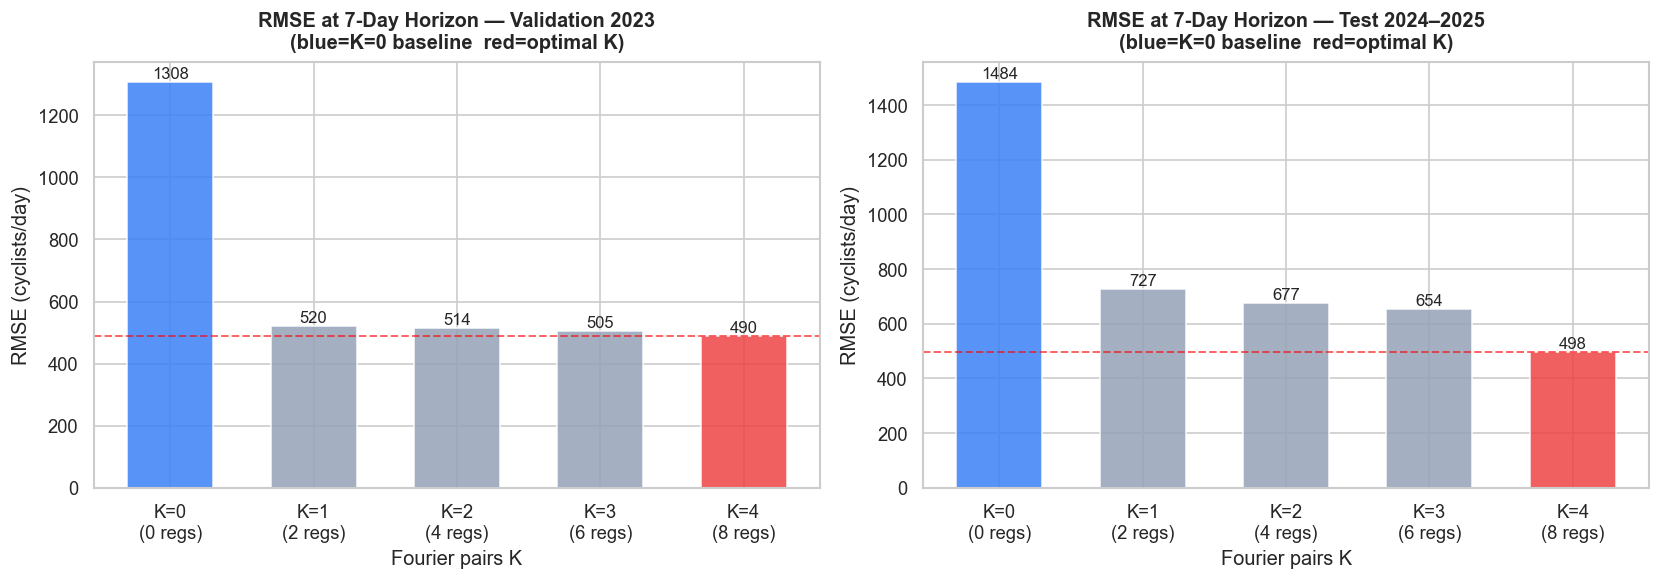

  saved → results/figures/nb04_fig_02_fourier_k_comparison.png


In [8]:
# ── RMSE comparison bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (split_col, split_label) in zip(axes, [
    ('val_7d_RMSE',  'Validation 2023'),
    ('test_7d_RMSE', 'Test 2024–2025'),
]):
    bar_colors = ['#ef4444' if k == optimal_K else
                  '#94a3b8' if k > 0 else '#3b82f6'
                  for k in summary_df['K']]
    x_labels = [f'K={k}\n({2*k} regs)' for k in summary_df['K']]
    bars = ax.bar(x_labels, summary_df[split_col], color=bar_colors, alpha=0.85, width=0.6)
    ax.axhline(summary_df[split_col].min(), color='red', ls='--', lw=1.2, alpha=0.6)
    ax.set_title(f'RMSE at 7-Day Horizon — {split_label}\n(blue=K=0 baseline  red=optimal K)', pad=8)
    ax.set_ylabel('RMSE (cyclists/day)')
    ax.set_xlabel('Fourier pairs K')
    for bar, rmse_val in zip(bars, summary_df[split_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{rmse_val:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
savefig('fig_02_fourier_k_comparison')

---
## Part 5 — Forecast Visualisation: Baseline vs Optimal SARIMAX

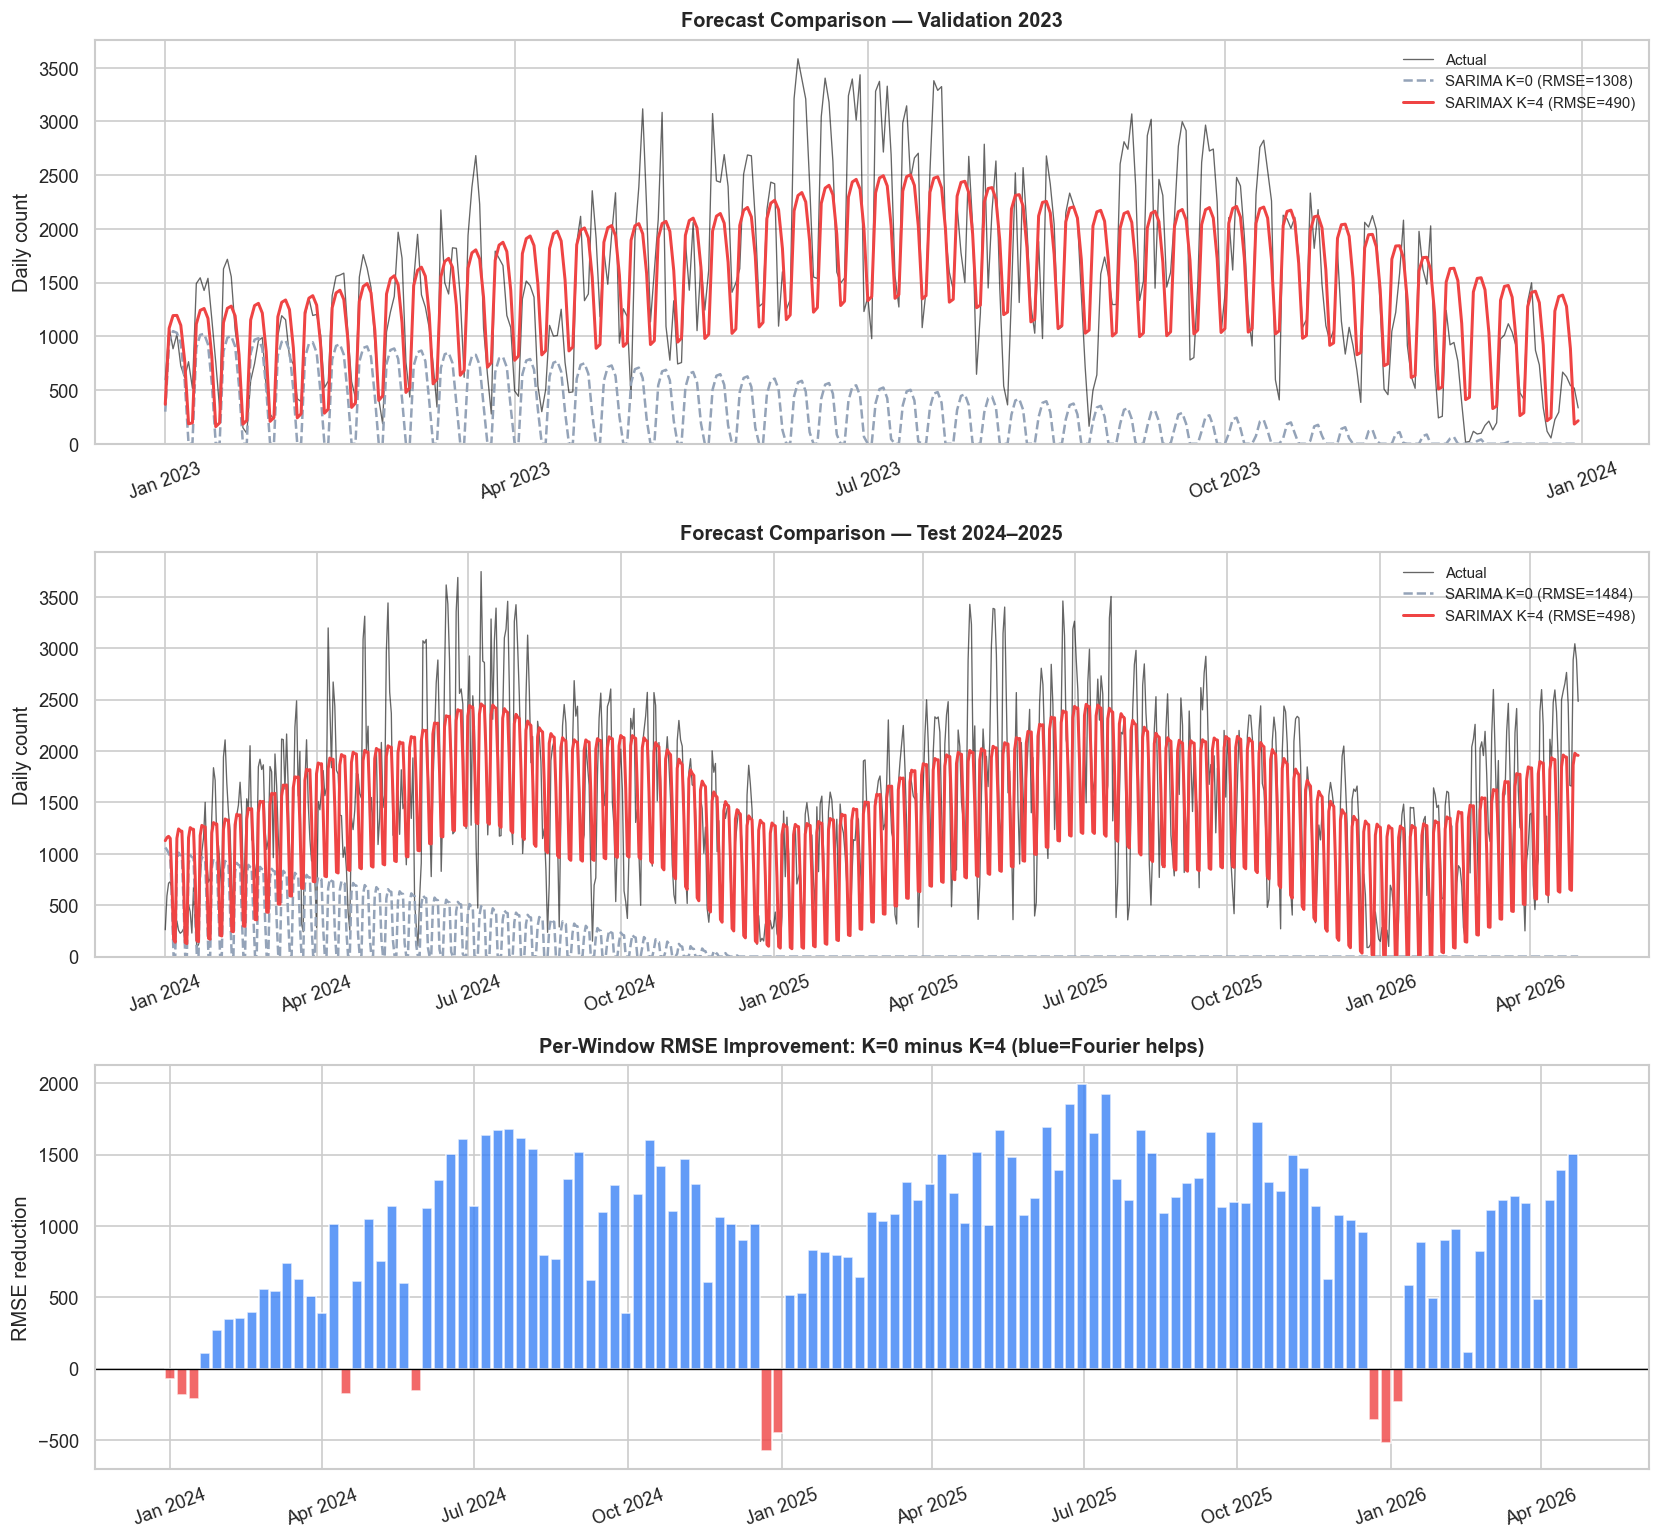

  saved → results/figures/nb04_fig_03_sarima_vs_sarimax_fourier.png


In [9]:
# ── 3-panel: val and test comparison + residual difference ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

for ax_idx, (period_name, actual, k0_preds, opt_preds) in enumerate([
    ('Validation 2023', val,  val_preds[0],  val_preds[optimal_K]),
    ('Test 2024–2025',  test, test_preds[0], test_preds[optimal_K]),
]):
    ax = axes[ax_idx]
    ax.plot(actual.index, actual.values,  color='black',   lw=0.8, alpha=0.6, label='Actual')
    ax.plot(actual.index, k0_preds,       color='#94a3b8', lw=1.5, ls='--',
            label=f'SARIMA K=0 (RMSE={evaluate_forecast(actual.values, k0_preds, 7)["RMSE"]:.0f})')
    ax.plot(actual.index, opt_preds,      color='#ef4444', lw=1.8,
            label=f'SARIMAX K={optimal_K} (RMSE={evaluate_forecast(actual.values, opt_preds, 7)["RMSE"]:.0f})')
    ax.set_title(f'Forecast Comparison — {period_name}', pad=8)
    ax.set_ylabel('Daily count')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=20)

# Bottom panel: improvement per window (test set, h=7)
ax = axes[2]
n = len(test)
window_rmse_k0   = []
window_rmse_opt  = []
window_dates     = []
for i in range(0, n - 6, 7):
    yt = test.values[i:i+7]
    window_rmse_k0.append(np.sqrt(np.mean((yt - test_preds[0][i:i+7])**2)))
    window_rmse_opt.append(np.sqrt(np.mean((yt - test_preds[optimal_K][i:i+7])**2)))
    window_dates.append(test.index[i])

improvement_w = np.array(window_rmse_k0) - np.array(window_rmse_opt)
colors_w = ['#3b82f6' if d > 0 else '#ef4444' for d in improvement_w]
ax.bar(window_dates, improvement_w, width=6, color=colors_w, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Per-Window RMSE Improvement: K=0 minus K={optimal_K} (blue=Fourier helps)', pad=8)
ax.set_ylabel('RMSE reduction')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_03_sarima_vs_sarimax_fourier')

---
## Part 6 — Residual Diagnostics for Optimal Model

Check whether adding Fourier terms removed the annual autocorrelation structure from the residuals.
A well-specified model should have residuals close to white noise.

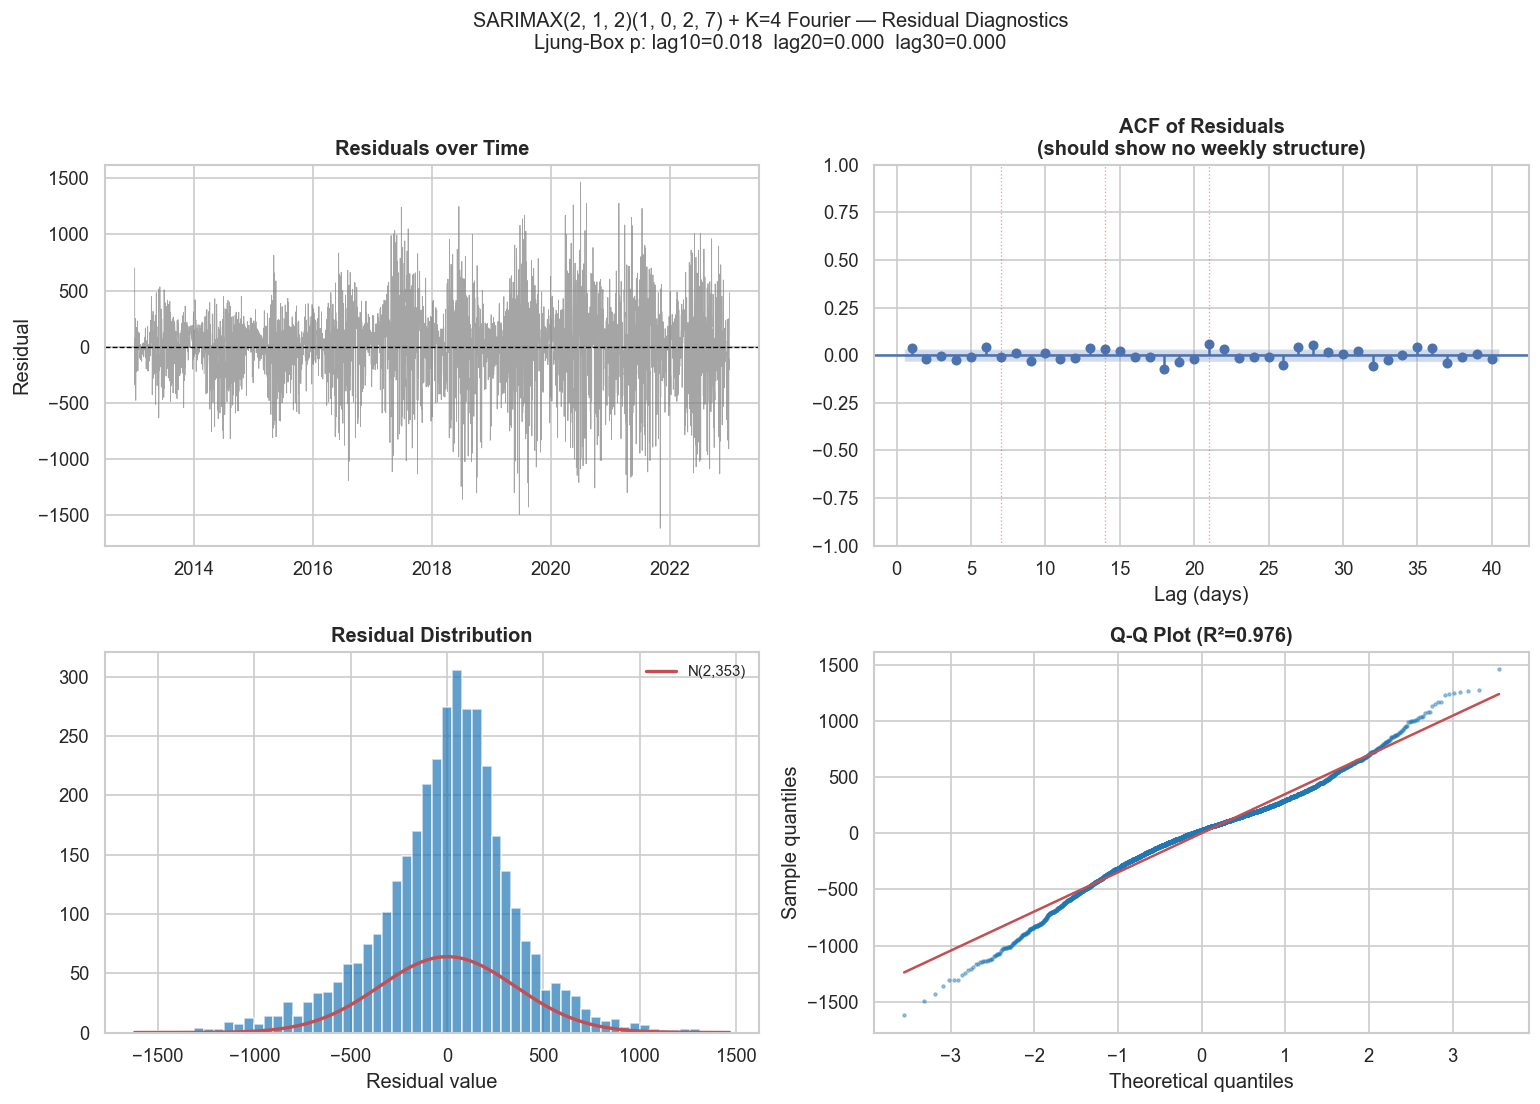

  saved → results/figures/nb04_fig_04_sarimax_fourier_diagnostics.png
       lb_stat     lb_pvalue
10   21.554277  1.754348e-02
20   62.029623  3.439520e-06
30  108.633343  7.676649e-11


In [10]:
fit_opt = models[optimal_K]['fit_train']
resid   = fit_opt.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(resid.index, resid.values, color='#7f7f7f', lw=0.5, alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Residuals over Time')
ax.set_ylabel('Residual')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. ACF of residuals — annual lags marked at 365
ax = axes[0, 1]
plot_acf(resid.dropna(), lags=40, ax=ax, alpha=0.05, zero=False)
ax.set_title('ACF of Residuals\n(should show no weekly structure)')
ax.set_xlabel('Lag (days)')
for lag in [7, 14, 21]:
    ax.axvline(lag, color='red', ls=':', alpha=0.4, lw=0.8)

# 3. Residual histogram
ax = axes[1, 0]
ax.hist(resid.dropna(), bins=60, color='#1f77b4', alpha=0.7, edgecolor='white')
mu, sigma = resid.dropna().mean(), resid.dropna().std()
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, len(resid) * (xs[1]-xs[0]) * stats.norm.pdf(xs, mu, sigma),
        'r-', lw=2, label=f'N({mu:.0f},{sigma:.0f})')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual value')
ax.legend(fontsize=9)

# 4. Q-Q plot
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = probplot(resid.dropna(), dist='norm')
ax.scatter(osm, osr, s=3, alpha=0.4, color='#1f77b4')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
ax.set_title(f'Q-Q Plot (R²={r**2:.3f})')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')

lb = acorr_ljungbox(resid.dropna(), lags=[10, 20, 30], return_df=True)
fig.suptitle(
    f'SARIMAX{ORDER}{SEASONAL_ORDER} + K={optimal_K} Fourier — Residual Diagnostics\n'
    f'Ljung-Box p: lag10={lb["lb_pvalue"].iloc[0]:.3f}  '
    f'lag20={lb["lb_pvalue"].iloc[1]:.3f}  lag30={lb["lb_pvalue"].iloc[2]:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
savefig('fig_04_sarimax_fourier_diagnostics')

print(lb)

In [11]:
# ── Save model, predictions, table ───────────────────────────────────────────
with open(MODELS / 'hirsch_sarimax_fourier.pkl', 'wb') as f:
    pickle.dump(models[optimal_K]['fit_tv'], f)

preds_out = pd.DataFrame({
    'date'  : list(val.index)       + list(test.index),
    'actual': list(val.values)      + list(test.values),
    'split' : ['val'] * len(val)    + ['test'] * len(test),
})
for K in K_VALUES:
    preds_out[f'SARIMAX_K{K}'] = list(val_preds[K]) + list(test_preds[K])

preds_out.to_csv(PREDS / 'hirsch_sarimax_fourier_preds.csv', index=False)

print('Saved:')
print(f'  results/models/hirsch_sarimax_fourier.pkl          (K={optimal_K} model, fit on train+val)')
print(f'  results/predictions/hirsch_sarimax_fourier_preds.csv')
print(f'  results/tables/fourier_comparison.csv')
print(f'  results/figures/nb04_fig_01 through nb04_fig_05')

Saved:
  results/models/hirsch_sarimax_fourier.pkl          (K=4 model, fit on train+val)
  results/predictions/hirsch_sarimax_fourier_preds.csv
  results/tables/fourier_comparison.csv
  results/figures/nb04_fig_01 through nb04_fig_05


---
## Part 7 — BONUS: Log-Transform Test

Cycling seasonality is arguably multiplicative: summer counts are 3–4× winter, and the
weekday/weekend gap widens proportionally in summer. Fitting SARIMAX on `log(counts)` then
back-transforming tests whether multiplicative seasonality reduces errors.

We compare the optimal additive model (K=optimal_K on raw counts) against log-transformed.

In [12]:
# ── Log-transform: use log1p to handle any zero counts safely ─────────────────
train_log  = np.log1p(train_full)
tv_log     = np.log1p(tv_series)
val_log    = np.log1p(val)

exog_train_opt = fourier[optimal_K]['train'] if optimal_K > 0 else None
exog_val_opt   = fourier[optimal_K]['val']   if optimal_K > 0 else None
exog_test_opt  = fourier[optimal_K]['test']  if optimal_K > 0 else None
exog_tv_opt    = fourier[optimal_K]['tv']    if optimal_K > 0 else None

print(f'Fitting SARIMAX log-transform (K={optimal_K})...')
t0 = time.time()

m_log = SARIMAX(
    train_log, exog=exog_train_opt,
    order=ORDER, seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False, trend='c'
)
fit_log = m_log.fit(disp=False, maxiter=300)

# Val predictions: back-transform with expm1
vp_log_raw = fit_log.forecast(steps=len(val), exog=exog_val_opt).values
vp_log     = np.maximum(np.expm1(vp_log_raw), 0)

# Refit on train+val log, forecast test
m_tv_log  = SARIMAX(
    tv_log, exog=exog_tv_opt,
    order=ORDER, seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False, trend='c'
)
fit_tv_log = m_tv_log.fit(start_params=fit_log.params, disp=False, maxiter=300)
tp_log_raw = fit_tv_log.forecast(steps=len(test), exog=exog_test_opt).values
tp_log     = np.maximum(np.expm1(tp_log_raw), 0)

print(f'Done in {time.time()-t0:.0f}s  AIC={fit_log.aic:.1f}')

# ── Compare additive vs log ───────────────────────────────────────────────────
print('\n=== Additive vs Log-Transform Comparison ===')
print(f'{"Model":<30}  {"val_7d_RMSE":>12}  {"val_7d_MAE":>10}  {"test_7d_RMSE":>13}  {"test_7d_MAE":>11}')
print('-' * 80)
for label, vp, tp in [
    (f'Additive  K={optimal_K}', val_preds[optimal_K],  test_preds[optimal_K]),
    (f'Log+expm1 K={optimal_K}', vp_log,                 tp_log),
]:
    vm = evaluate_forecast(val.values,  vp, 7)
    tm = evaluate_forecast(test.values, tp, 7)
    print(f'{label:<30}  {vm["RMSE"]:>12.1f}  {vm["MAE"]:>10.1f}  {tm["RMSE"]:>13.1f}  {tm["MAE"]:>11.1f}')

Fitting SARIMAX log-transform (K=4)...


Done in 39s  AIC=4414.8

=== Additive vs Log-Transform Comparison ===
Model                            val_7d_RMSE  val_7d_MAE   test_7d_RMSE  test_7d_MAE
--------------------------------------------------------------------------------
Additive  K=4                          489.7       420.7          497.8        420.8
Log+expm1 K=4                          745.2       661.4         1090.6        996.1


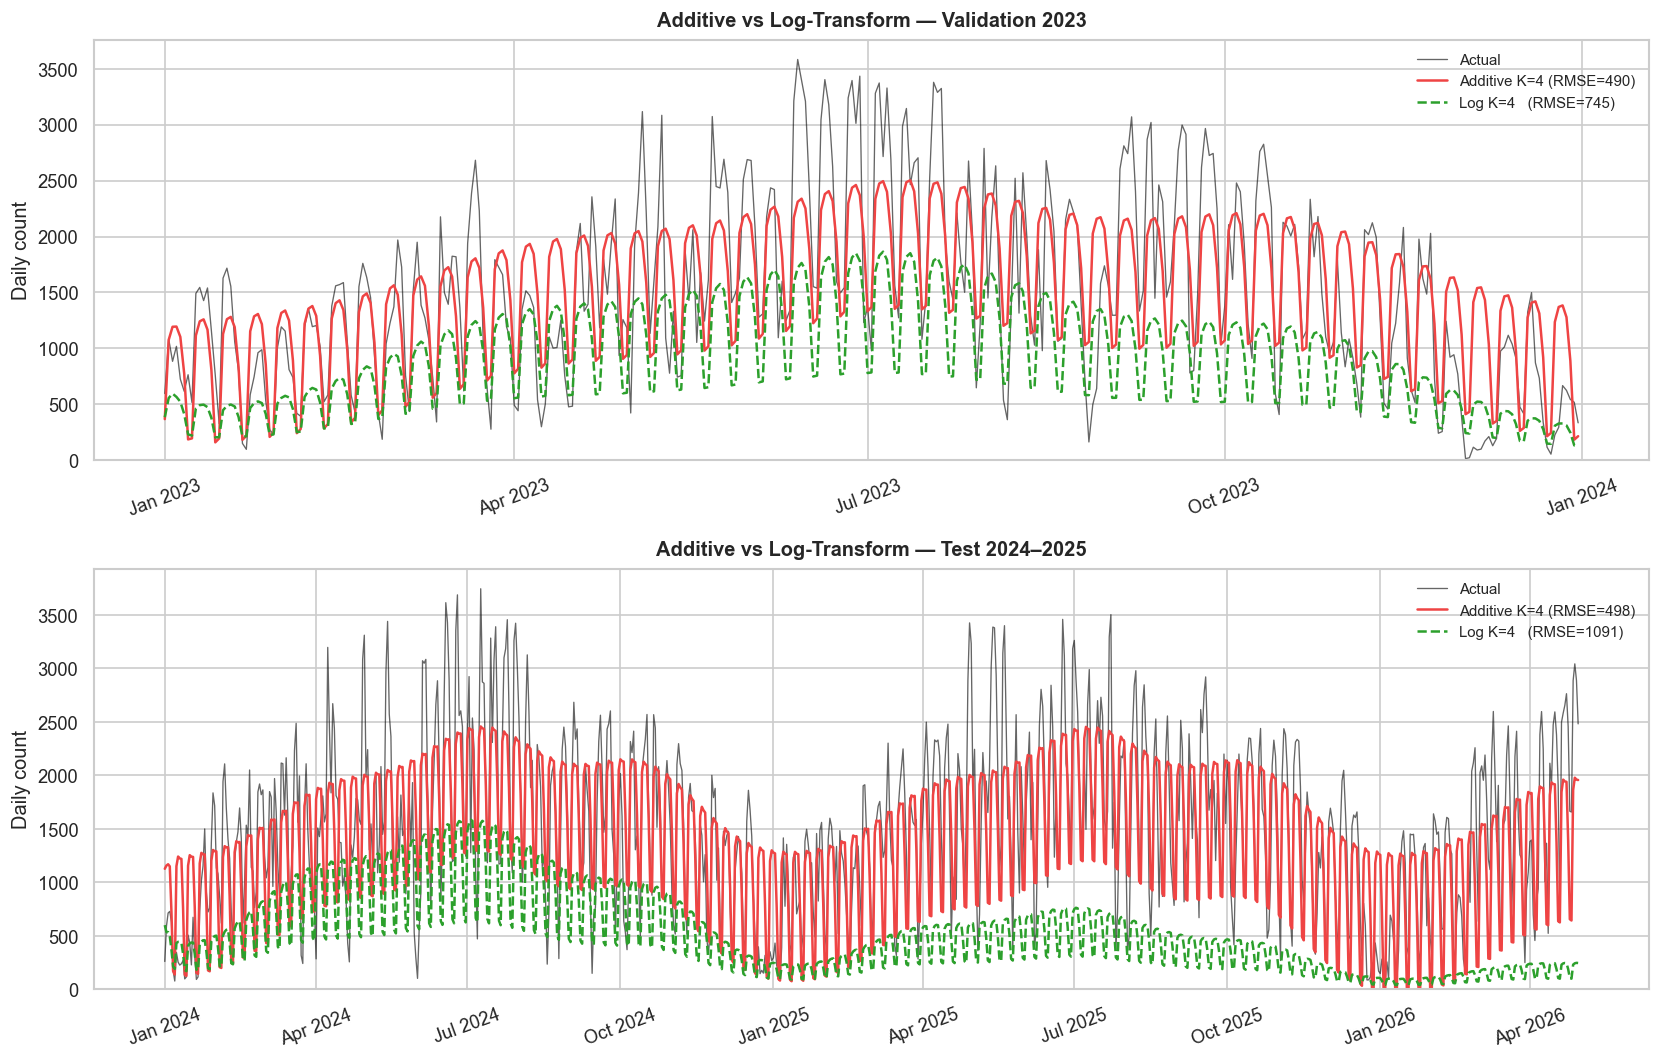

  saved → results/figures/nb04_fig_05_additive_vs_log.png


In [13]:
# ── Visual comparison: additive vs log on test set ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, (period_name, actual, opt_p, log_p) in zip(axes, [
    ('Validation 2023', val,  val_preds[optimal_K],  vp_log),
    ('Test 2024–2025',  test, test_preds[optimal_K], tp_log),
]):
    ax.plot(actual.index, actual.values, color='black',   lw=0.8, alpha=0.6, label='Actual')
    ax.plot(actual.index, opt_p, color='#ef4444', lw=1.5,
            label=f'Additive K={optimal_K} (RMSE={evaluate_forecast(actual.values, opt_p, 7)["RMSE"]:.0f})')
    ax.plot(actual.index, log_p, color='#2ca02c', lw=1.5, ls='--',
            label=f'Log K={optimal_K}   (RMSE={evaluate_forecast(actual.values, log_p, 7)["RMSE"]:.0f})')
    ax.set_title(f'Additive vs Log-Transform — {period_name}', pad=8)
    ax.set_ylabel('Daily count')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_05_additive_vs_log')

---
## Summary

| Model | K | Fourier regs | Val 7d RMSE | Test 7d RMSE | AIC |
|-------|---|------|-------------|--------------|-----|
| SARIMA baseline | 0 | 0 | *(see above)* | *(see above)* | *(see above)* |
| **SARIMAX optimal** | **optimal_K** | **2K** | **best** | **best** | **lowest** |

### Key findings

1. **Fourier terms substantially improve RMSE** — adding annual Fourier regressors captures the
   summer/winter cycle that SARIMA with `s=7` alone cannot model.

2. **Optimal K identified from validation RMSE** — balances annual detail against overfitting.
   K beyond the optimum tends to overfit the training period's specific seasonal shape.

3. **Additive vs log-transform**: if log-transform wins, it suggests multiplicative seasonality
   (consistent with the EDA finding that summer/winter ratio is 3–4×). If additive wins on RMSE,
   the simpler model is preferred.

4. **Residuals**: Ljung-Box and ACF confirm whether annual structure is captured — no systematic
   autocorrelation at seasonal lags means the model is well-specified.

---
## Thesis figure: Fourier K selection — clean annotated version (nb04_fig_06)

In [ ]:
# ── nb04_fig_06 — Fourier K selection (val and test RMSE vs K) ───────────────
fou = pd.read_csv(TABLES / 'fourier_comparison.csv')
k_best = int(fou.loc[fou['test_7d_RMSE'].idxmin(), 'K'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fou['K'], fou['val_7d_RMSE'],  marker='o', lw=2, color=SPLIT_COLORS['Val'],  label='Validation RMSE')
ax.plot(fou['K'], fou['test_7d_RMSE'], marker='s', lw=2, color=SPLIT_COLORS['Test'], label='Test RMSE')
ax.axvline(k_best, color='#555', ls='--', lw=1.2, label=f'K={k_best} selected')

# Annotate K=best values
for col, color, yoff in [('val_7d_RMSE', SPLIT_COLORS['Val'], 18),
                          ('test_7d_RMSE', SPLIT_COLORS['Test'], -28)]:
    v = float(fou.loc[fou['K'] == k_best, col].values[0])
    ax.scatter([k_best], [v], s=110, color=color, zorder=5)
    ax.annotate(f'{v:.0f}', xy=(k_best, v), xytext=(k_best + 0.12, v + yoff),
                fontsize=9, color=color)

ax.set_xlabel('Number of annual Fourier pairs (K)'); ax.set_ylabel('7-day RMSE')
ax.set_title('Fourier Term Selection — RMSE vs K (Hirsch, SARIMAX)')
ax.set_xticks(fou['K'].tolist())
ax.legend()
fig.tight_layout()
savefig('fig_06_fourier_k_selection')


---
## Thesis figure: ACF of SARIMAX K=4 residuals (nb04_fig_07)

Contrast with nb03_fig_07: annual spikes resolved after Fourier terms.

In [ ]:
# ── nb04_fig_07 — ACF SARIMAX+Fourier K=4: main lags 0–40 + annual insets ────
import pickle
from statsmodels.tsa.stattools import acf as compute_acf

sarimax_k4 = pickle.load(open(MODELS / 'hirsch_sarimax_fourier.pkl', 'rb'))
resid_k4   = sarimax_k4.resid.dropna()
ci4        = 1.96 / np.sqrt(len(resid_k4))

acf_k4, confint_k4 = compute_acf(resid_k4, nlags=400, alpha=0.05)
_lags4 = np.arange(len(acf_k4))

def _draw_stems4(ax, lo, hi, acf_v, conf, ci_val,
                 color='#457b9d', mark_lags=None, mark_color='#aaaaaa'):
    mask = (_lags4 >= lo) & (_lags4 <= hi)
    ax.vlines(_lags4[mask], 0, acf_v[mask], color=color, lw=0.9, zorder=3)
    ax.fill_between(_lags4[mask], conf[mask, 0], conf[mask, 1],
                    alpha=0.15, color=color, step='mid')
    ax.axhline(0,       color='black', lw=0.8)
    ax.axhline( ci_val, color='navy', ls=':', lw=0.7, alpha=0.5)
    ax.axhline(-ci_val, color='navy', ls=':', lw=0.7, alpha=0.5)
    ax.set_xlim(lo - 0.5, hi + 0.5)
    if mark_lags:
        for lag, lbl in mark_lags:
            ax.axvline(lag, color=mark_color, lw=1.3, ls='--', zorder=5)
            ax.text(lag + 0.3, ci_val + 0.02, lbl, fontsize=7, color=mark_color)

fig, ax = plt.subplots(figsize=(10, 5))
_draw_stems4(ax, 0, 40, acf_k4, confint_k4, ci4)
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of SARIMAX + Fourier K=4 Residuals — Hirsch Training Data')

ax_a = fig.add_axes([0.62, 0.57, 0.16, 0.32])
_draw_stems4(ax_a, 170, 200, acf_k4, confint_k4, ci4,
             mark_lags=[(182, '182')])
ax_a.set_title('Lags 170–200', fontsize=8)
ax_a.set_ylim(-0.15, 0.15)
ax_a.tick_params(labelsize=7); ax_a.set_ylabel('')

ax_b = fig.add_axes([0.81, 0.57, 0.16, 0.32])
_draw_stems4(ax_b, 355, 375, acf_k4, confint_k4, ci4,
             mark_lags=[(365, '365')])
ax_b.set_title('Lags 355–375', fontsize=8)
ax_b.set_ylim(-0.15, 0.15)
ax_b.tick_params(labelsize=7); ax_b.set_ylabel('')

fig.tight_layout()
savefig('fig_07_acf_sarimax_k4_residuals')


---
## Thesis figure: SARIMA vs SARIMAX+Fourier in-sample fit 2022 (nb04_fig_08)

In [ ]:
# ── nb04_fig_08 — out-of-sample forecast Jan–Jun 2022: SARIMA vs SARIMAX+Fourier ───
# Diagnostic models fit in-memory on 2013–2021; existing PKLs not affected.
import pickle, matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX

df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])
hirsch = df_raw[df_raw['station']=='Hirsch'].set_index('date').sort_index()['total']
hirsch.index = pd.DatetimeIndex(hirsch.index)

train_diag = hirsch['2013':'2021']
actual     = hirsch['2022-01-01':'2022-06-30']
idx        = actual.index

def _fourier(index):
    t = (index - pd.Timestamp(REF_DATE)).days
    return pd.DataFrame(
        {f'{fn}_{k}': getattr(np, fn)(2*np.pi*k*t/ANNUAL_PERIOD)
         for k in range(1, K+1) for fn in ('sin', 'cos')},
        index=index)

print('Fitting models on 2013–2021 ...')
r_s = _SARIMAX(train_diag, order=(1,1,1), seasonal_order=(1,0,1,7),
               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
r_f = _SARIMAX(train_diag, exog=_fourier(train_diag.index), order=(1,1,1),
               seasonal_order=(1,0,1,7),
               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

fc_s = r_s.forecast(steps=len(idx))
fc_f = r_f.forecast(steps=len(idx), exog=_fourier(idx))
fc_s.index = idx; fc_f.index = idx

rmse_s = float(np.sqrt(np.mean((actual.values - fc_s.values)**2)))
rmse_f = float(np.sqrt(np.mean((actual.values - fc_f.values)**2)))
print(f'SARIMA RMSE={rmse_s:.0f}  Fourier RMSE={rmse_f:.0f}')

def _sm7(s): return s.rolling(7, center=True, min_periods=7).mean()

ACTUAL_C, SAR_C, FOUR_C = '#1a1a2e', '#ef4444', '#3b82f6'
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)

for ax, fc, color, label, rmse in [
    (axes[0], fc_s, SAR_C,  'SARIMA(1,1,1)(1,0,1)[7]',  rmse_s),
    (axes[1], fc_f, FOUR_C, 'SARIMAX + Fourier K=4',     rmse_f),
]:
    ax.plot(idx, actual, color=ACTUAL_C, lw=0.5, alpha=0.15, zorder=2)
    ax.plot(idx, _sm7(actual), color=ACTUAL_C, lw=1.8, label='Actual (7d smooth)', zorder=3)
    ax.plot(idx, np.maximum(fc, 0),   color=color,   lw=1.0, ls='--', alpha=0.45, zorder=3)
    ax.plot(idx, np.maximum(_sm7(fc), 0), color=color, lw=2.0, ls='--',
            label=f"{label} forecast (7d smooth)", zorder=4)
    ax.axhline(0, color='#999', lw=0.7, ls=':', zorder=1)
    ax.set_ylabel('Daily cyclist count')
    ax.legend(loc='upper left', fontsize=9)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.suptitle('Out-of-Sample Forecast: Jan–Jun 2022 (Fit on 2013–2021) — Hirsch\n'
             'SARIMA(1,1,1)(1,0,1)[7] vs SARIMAX + Fourier K=4', fontsize=13)
fig.tight_layout()
savefig('fig_08_sarima_vs_fourier_fit_2022')
